<a href="https://colab.research.google.com/github/SwaksharDebnath/CRF-for-Bangla-Ancholik-NER-/blob/main/EDA_noakhali.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import os
import random

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/NER_Dataset/CSV_data/Noakhali_NER.csv')


df['Sentence #'] = df['Sentence #'].ffill()

sentences = [group for _, group in df.groupby('Sentence #', sort=False)]

# Shuffle the sentences
random.seed(42)  # For reproducibility
random.shuffle(sentences)

# Split 80:20
split_idx = int(len(sentences) * 0.8)
train_sentences = sentences[:split_idx]
test_sentences = sentences[split_idx:]

train_df = pd.concat(train_sentences)
test_df = pd.concat(test_sentences)

# Revert the 'Sentence #' column back to its original format (only first word has the ID)
def revert_format(data):
    mask = data['Sentence #'] != data['Sentence #'].shift(1)
    data_out = data.copy()
    data_out.loc[~mask, 'Sentence #'] = ''
    return data_out

train_df = revert_format(train_df)
test_df = revert_format(test_df)

# Save to separate CSV files
train_df.to_csv('/content/drive/MyDrive/NER_Dataset/CSV_data/train/Noakhali_NER_train.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/NER_Dataset/CSV_data/test/Noakhali_NER_test.csv', index=False)

print(f"Total sentences: {len(sentences)}")
print(f"Train sentences: {len(train_sentences)} (80%)")
print(f"Test sentences: {len(test_sentences)} (20%)")


Total sentences: 3481
Train sentences: 2784 (80%)
Test sentences: 697 (20%)


In [5]:
def convert_csv_to_conll(csv_path, output_path):
    df = pd.read_csv(csv_path)

    with open(output_path, 'w', encoding='utf-8') as f:
        first_word = True

        for index, row in df.iterrows():
            sentence_id = row['Sentence #']
            word = row['noakhali_word']
            tag = row['bio_tag']


            if pd.notna(sentence_id) and str(sentence_id).strip().startswith("Sentence:"):

                if not first_word:
                    f.write("\n")


            if pd.isna(word):
                continue


            f.write(f"{word} _ _ {tag}\n")

            first_word = False

        # Add a final newline at the end of the file
        f.write("\n")

    print(f"Conversion complete! File saved to {output_path}")

In [6]:
convert_csv_to_conll('/content/drive/MyDrive/NER_Dataset/CSV_data/train/Noakhali_NER_train.csv', '/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/train/Noakhali_NER_train.txt')
convert_csv_to_conll('/content/drive/MyDrive/NER_Dataset/CSV_data/test/Noakhali_NER_test.csv', '/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/test/Noakhali_NER_test.txt')

Conversion complete! File saved to /content/drive/MyDrive/NER_Dataset/ConvertedTxtData/train/Noakhali_NER_train.txt
Conversion complete! File saved to /content/drive/MyDrive/NER_Dataset/ConvertedTxtData/test/Noakhali_NER_test.txt


In [7]:
def load_dataset(filename):
    with open(filename) as file:
        lines = [x.strip() for x in file.readlines()]

    words = []
    labels = []

    total = 0
    for l in lines:

        if l == "":
            total += 1
            continue
        else:
            words += [l.split(" _ _ ")[0]]
            labels += [l.split(" _ _ ")[1]]

    total+=1
    label_set = list(set(labels))
    label_types = [x.split('-')[1] for x in labels if len(x) > 1]

    print(filename)
    print('total:', total)
    print('label set:', label_set)
    print('label types:', set(label_types))
    print('label distribution:')
    for l in sorted(label_set):
        if l != 'X':
            print(l, ":",  "%.2f" % (labels.count(l)/ len(labels) * 100), "%")

    print('label types distribution:')
    for l in set(label_types):
        print(l, ":", "%.2f" % (label_types.count(l) / len(labels) * 100), "%")
    return words, labels, label_set

In [8]:
train_words, train_labels, train_label_set = load_dataset('/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/train/Noakhali_NER_train.txt')

/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/train/Noakhali_NER_train.txt
total: 2785
label set: ['B-REL', 'I-ORG', 'B-ROLE', 'I-COL', 'I-REL', 'I-LOC', 'B-LOC', 'I-ROLE', 'I-OBJ', 'I-FOOD', 'B-COL', 'B-FOOD', 'B-ORG', 'B-PER', 'B-ANI', 'O', 'I-ANI', 'B-OBJ', 'I-PER']
label types: {'PER', 'COL', 'FOOD', 'ANI', 'ORG', 'LOC', 'OBJ', 'REL', 'ROLE'}
label distribution:
B-ANI : 0.25 %
B-COL : 0.59 %
B-FOOD : 1.29 %
B-LOC : 1.59 %
B-OBJ : 1.65 %
B-ORG : 0.54 %
B-PER : 0.17 %
B-REL : 2.84 %
B-ROLE : 0.41 %
I-ANI : 0.04 %
I-COL : 0.23 %
I-FOOD : 0.27 %
I-LOC : 0.25 %
I-OBJ : 0.14 %
I-ORG : 0.12 %
I-PER : 0.02 %
I-REL : 0.36 %
I-ROLE : 0.17 %
O : 89.05 %
label types distribution:
PER : 0.19 %
COL : 0.81 %
FOOD : 1.56 %
ANI : 0.30 %
ORG : 0.67 %
LOC : 1.84 %
OBJ : 1.79 %
REL : 3.21 %
ROLE : 0.59 %


In [9]:
test_words, test_labels, test_label_set = load_dataset('/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/test/Noakhali_NER_test.txt')

/content/drive/MyDrive/NER_Dataset/ConvertedTxtData/test/Noakhali_NER_test.txt
total: 698
label set: ['B-PER', 'B-REL', 'I-REL', 'B-COL', 'B-ANI', 'B-FOOD', 'I-LOC', 'I-ORG', 'B-ORG', 'B-ROLE', 'O', 'B-LOC', 'I-ANI', 'B-OBJ', 'I-COL', 'I-ROLE', 'I-OBJ', 'I-FOOD']
label types: {'PER', 'COL', 'FOOD', 'ANI', 'ORG', 'LOC', 'OBJ', 'REL', 'ROLE'}
label distribution:
B-ANI : 0.20 %
B-COL : 0.58 %
B-FOOD : 1.19 %
B-LOC : 1.27 %
B-OBJ : 1.44 %
B-ORG : 0.61 %
B-PER : 0.20 %
B-REL : 3.47 %
B-ROLE : 0.33 %
I-ANI : 0.03 %
I-COL : 0.23 %
I-FOOD : 0.08 %
I-LOC : 0.33 %
I-OBJ : 0.08 %
I-ORG : 0.23 %
I-REL : 0.48 %
I-ROLE : 0.08 %
O : 89.19 %
label types distribution:
PER : 0.20 %
COL : 0.81 %
FOOD : 1.27 %
ANI : 0.23 %
ORG : 0.84 %
LOC : 1.59 %
OBJ : 1.52 %
REL : 3.95 %
ROLE : 0.41 %


In [10]:
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns


def plot_all_labels(label_set, all_labels):

    index_to_labels = {}
    for i in range(len(label_set)):
        index_to_labels[i] = label_set[i]

    print(index_to_labels)

    label_to_index = {}
    for key in index_to_labels:
        label_to_index[index_to_labels[key]] = key
    print(label_to_index)

    arr = np.zeros(len(label_set))
    label_counts = Counter(all_labels)
    for key, value in label_counts.items():
        arr[label_to_index[key]] = value


    plt.figure(figsize=(30,5))
    ax = sns.barplot(x=np.arange(len(label_set)),y=arr)
    ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")
    ax.set(xlabel='Classes', ylabel='Class Counts')
    plt.show()

In [11]:
def plot_only_ne(label_set, all_labels):

    index_to_labels = {}
    i=0
    for x in label_set:
        if x == 'O':
            continue
        index_to_labels[i] = x
        i += 1

    print(index_to_labels)

    label_to_index = {}
    for key in index_to_labels:
        label_to_index[index_to_labels[key]] = key
    print(label_to_index)

    arr = np.zeros(len(label_set)-1)
    label_counts = Counter(all_labels)
    for key, value in label_counts.items():
        if key == 'O':
            continue
        arr[label_to_index[key]] = value


    plt.figure(figsize=(30,5))
    ax = sns.barplot(x=np.arange(len(label_set)-1),y=arr)
    ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")
    ax.set(xlabel='Classes', ylabel='Class Counts')
    plt.show()

{0: 'B-REL', 1: 'I-ORG', 2: 'B-ROLE', 3: 'I-COL', 4: 'I-REL', 5: 'I-LOC', 6: 'B-LOC', 7: 'I-ROLE', 8: 'I-OBJ', 9: 'I-FOOD', 10: 'B-COL', 11: 'B-FOOD', 12: 'B-ORG', 13: 'B-PER', 14: 'B-ANI', 15: 'O', 16: 'I-ANI', 17: 'B-OBJ', 18: 'I-PER'}
{'B-REL': 0, 'I-ORG': 1, 'B-ROLE': 2, 'I-COL': 3, 'I-REL': 4, 'I-LOC': 5, 'B-LOC': 6, 'I-ROLE': 7, 'I-OBJ': 8, 'I-FOOD': 9, 'B-COL': 10, 'B-FOOD': 11, 'B-ORG': 12, 'B-PER': 13, 'B-ANI': 14, 'O': 15, 'I-ANI': 16, 'B-OBJ': 17, 'I-PER': 18}


/tmp/ipykernel_12700/2007763826.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")


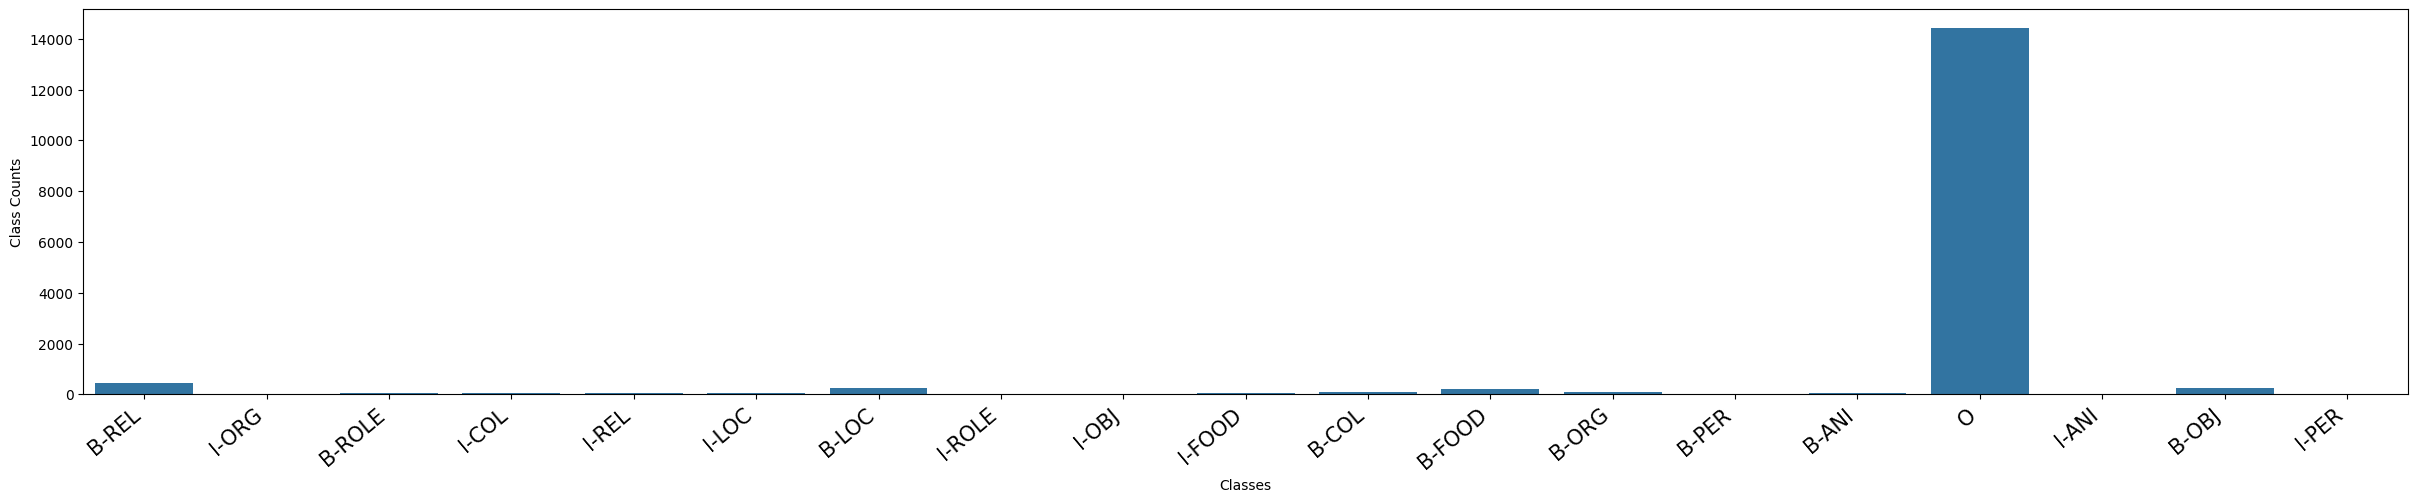

In [12]:
plot_all_labels(train_label_set, train_labels)

{0: 'B-REL', 1: 'I-ORG', 2: 'B-ROLE', 3: 'I-COL', 4: 'I-REL', 5: 'I-LOC', 6: 'B-LOC', 7: 'I-ROLE', 8: 'I-OBJ', 9: 'I-FOOD', 10: 'B-COL', 11: 'B-FOOD', 12: 'B-ORG', 13: 'B-PER', 14: 'B-ANI', 15: 'I-ANI', 16: 'B-OBJ', 17: 'I-PER'}
{'B-REL': 0, 'I-ORG': 1, 'B-ROLE': 2, 'I-COL': 3, 'I-REL': 4, 'I-LOC': 5, 'B-LOC': 6, 'I-ROLE': 7, 'I-OBJ': 8, 'I-FOOD': 9, 'B-COL': 10, 'B-FOOD': 11, 'B-ORG': 12, 'B-PER': 13, 'B-ANI': 14, 'I-ANI': 15, 'B-OBJ': 16, 'I-PER': 17}


/tmp/ipykernel_12700/1492828544.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")


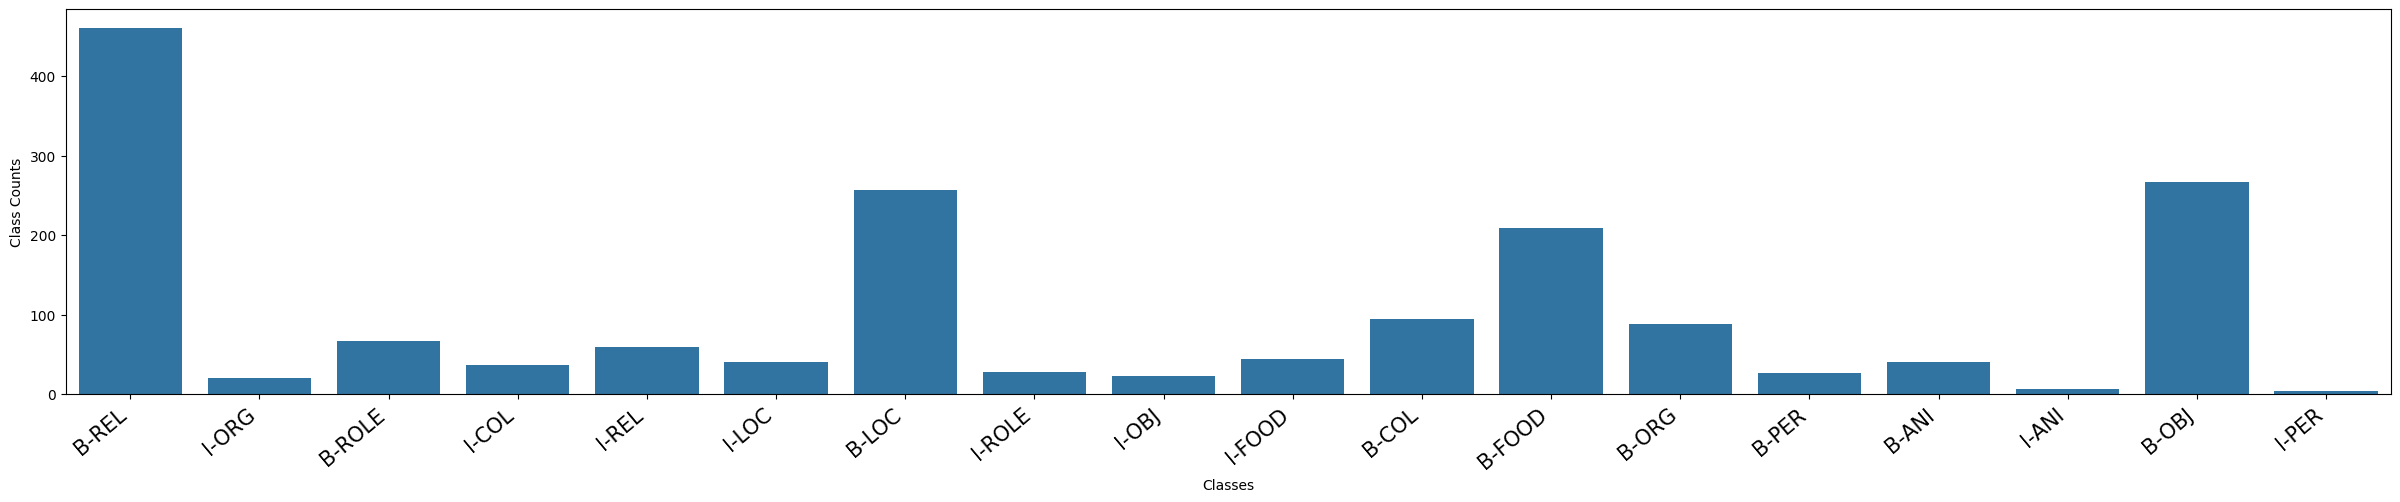

In [13]:
plot_only_ne(train_label_set, train_labels)

{0: 'B-PER', 1: 'B-REL', 2: 'I-REL', 3: 'B-COL', 4: 'B-ANI', 5: 'B-FOOD', 6: 'I-LOC', 7: 'I-ORG', 8: 'B-ORG', 9: 'B-ROLE', 10: 'O', 11: 'B-LOC', 12: 'I-ANI', 13: 'B-OBJ', 14: 'I-COL', 15: 'I-ROLE', 16: 'I-OBJ', 17: 'I-FOOD'}
{'B-PER': 0, 'B-REL': 1, 'I-REL': 2, 'B-COL': 3, 'B-ANI': 4, 'B-FOOD': 5, 'I-LOC': 6, 'I-ORG': 7, 'B-ORG': 8, 'B-ROLE': 9, 'O': 10, 'B-LOC': 11, 'I-ANI': 12, 'B-OBJ': 13, 'I-COL': 14, 'I-ROLE': 15, 'I-OBJ': 16, 'I-FOOD': 17}


/tmp/ipykernel_12700/2007763826.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")


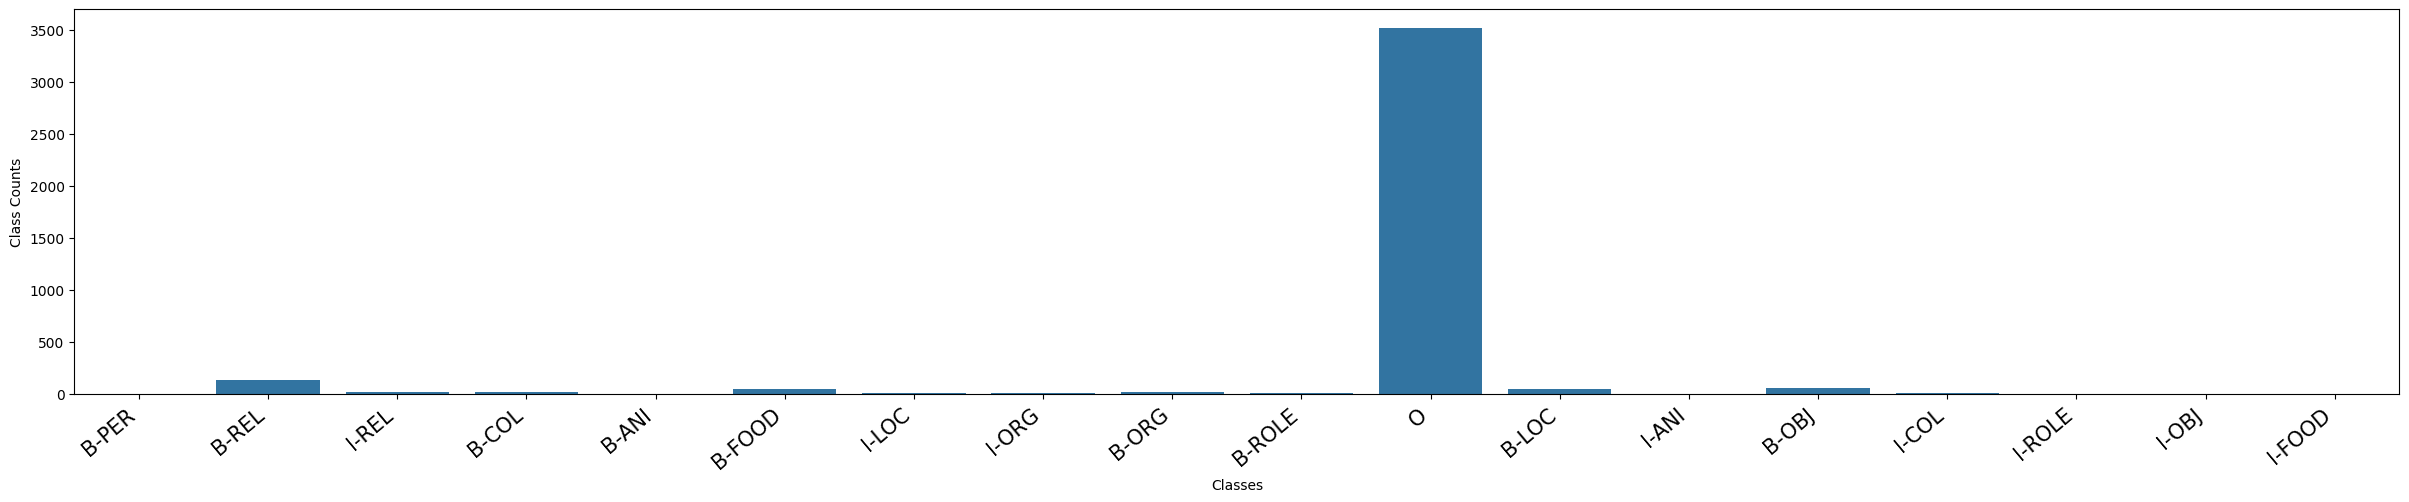

In [14]:
plot_all_labels(test_label_set, test_labels)

{0: 'B-PER', 1: 'B-REL', 2: 'I-REL', 3: 'B-COL', 4: 'B-ANI', 5: 'B-FOOD', 6: 'I-LOC', 7: 'I-ORG', 8: 'B-ORG', 9: 'B-ROLE', 10: 'B-LOC', 11: 'I-ANI', 12: 'B-OBJ', 13: 'I-COL', 14: 'I-ROLE', 15: 'I-OBJ', 16: 'I-FOOD'}
{'B-PER': 0, 'B-REL': 1, 'I-REL': 2, 'B-COL': 3, 'B-ANI': 4, 'B-FOOD': 5, 'I-LOC': 6, 'I-ORG': 7, 'B-ORG': 8, 'B-ROLE': 9, 'B-LOC': 10, 'I-ANI': 11, 'B-OBJ': 12, 'I-COL': 13, 'I-ROLE': 14, 'I-OBJ': 15, 'I-FOOD': 16}


/tmp/ipykernel_12700/1492828544.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(list(index_to_labels.values()), fontsize=15, rotation=40, ha="right")


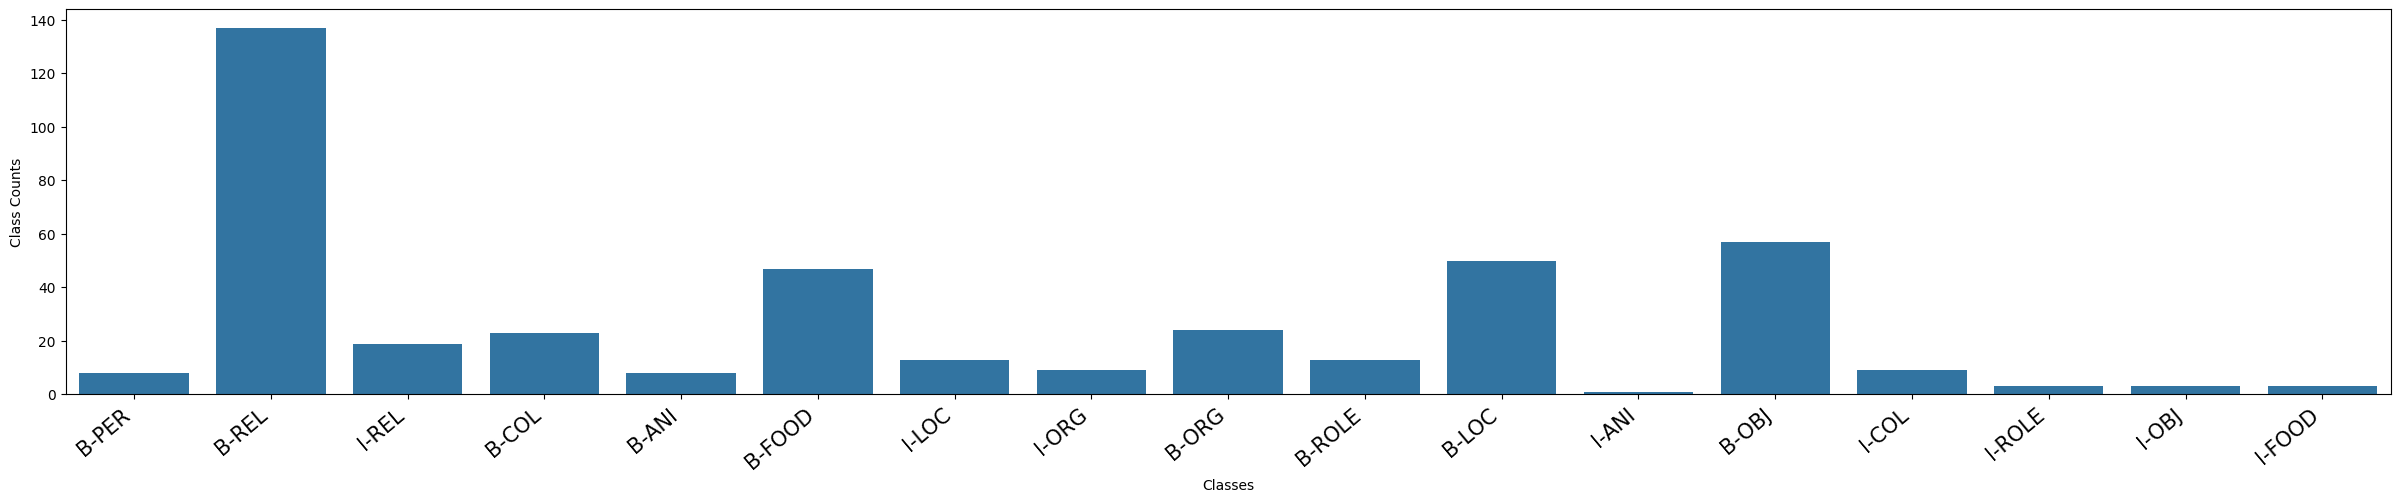

In [15]:
plot_only_ne(test_label_set, test_labels)